In [3]:
#pip install nbimporter

from transformers import AutoTokenizer, AutoModel
import torch
import nbimporter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import copy



In [4]:
all_party_textes_df = pd.read_parquet("all_parties_text_combined_prep_classified.parquet")
labled_theses_df = pd.read_parquet('wahlomat_thesen_prep.parquet')
Labled_theses_classification_df = pd.read_parquet('wahlomaten_thesen_positionen_classified.parquet')

labled_theses_df['Predicted_Class'] = Labled_theses_classification_df['Predicted_Class']
del Labled_theses_classification_df


In [5]:
lable_colums_list = labled_theses_df.columns[1:].tolist()

replace_dict = {
    'spd'   :   'SPD', 
    'cdu'   :   'CDU / CSU', 
    'gruene':   'GRÜNE', 
    'afd'   :   'AfD',
    'fdp'   :   'FDP', 
    'linke' :   'Die Linke'
}

all_party_textes_df['Party'] = all_party_textes_df['Party'].replace(replace_dict)
del replace_dict

In [6]:
# Load tokenizer and model
model_name = "mmmaurer/sbert-hashtag-german-politicians-2021"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)



def get_embedding(text:str, pooling_method:str = 'mean'):
    # Tokenize the input
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")

    # Get model output (embeddings)
    outputs = model(**inputs)

    # Extract the embeddings from the model output
    match pooling_method:
        case 'mean':
            return outputs.last_hidden_state.mean(dim=1).squeeze().detach().numpy()
        case 'max':
            return outputs.last_hidden_state.max(dim=1).values.squeeze().detach().numpy()
        case _:
            raise ValueError(f'The used pooling method ({pooling_method}) is not supported. Use "mean" or "max".')




c:\Users\Franziska Rudolf\Documents\Masterstudium Unterlagen\Text Mining\Textmining_Wahlprogramme\pupu\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Franziska Rudolf\.cache\huggingface\hub\models--mmmaurer--sbert-hashtag-german-politicians-2021. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import copy

def similarity_func_with_category_check(all_party_textes_df: pd.DataFrame, 
                                       labled_theses_df: pd.DataFrame, 
                                       lable_text_column: str, 
                                       party_text_column: str,
                                       plot: bool = False, 
                                       sort_by_classification: bool = False, 
                                       pooling_method: str = 'mean'):
    # Liste der Parteien und Thesen
    all_party_textes_df['Chapter'] = all_party_textes_df['Chapter'].fillna('-')
    parties_list = all_party_textes_df['Party'].unique().tolist()
    predicted_theses_df = copy.deepcopy(labled_theses_df)
    
    labled_text_list = labled_theses_df[lable_text_column].tolist()
    predicted_theses_dfs_dict = {}

    # Schleife über die Parteien
    for party_str in parties_list:
        # Filtern der Daten für die aktuelle Partei
        party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]

        # Entfernen von NaN-Werten
        party_df = party_df.dropna()

        # Extrahieren der Thesen für die aktuelle Partei
        party_text_list = party_df[party_text_column].to_list()

        # Erstellung eines DataFrames zur Berechnung der Ähnlichkeiten
        similarity_df = pd.DataFrame(columns=['party_text'] + labled_text_list)

        # Berechnung der Ähnlichkeit für jede Partei-These
        for party_text in party_text_list:
            party_text_embedding = get_embedding(party_text, pooling_method=pooling_method)
            row = [party_text]
            party_domain_num = party_df[party_df[party_text_column] == party_text]['Predicted_Class'].str[0].values[0]
            
            # Berechnung der Kosinusähnlichkeit für jede labelte These
            for label_text in labled_text_list:
                label_domain_num = labled_theses_df[labled_theses_df[lable_text_column] == label_text]['Predicted_Class'].str[0].values[0]
                label_text_embedding = get_embedding(label_text, pooling_method=pooling_method)
                similarity_score = cosine_similarity(party_text_embedding.reshape(1, -1), label_text_embedding.reshape(1, -1))[0][0]
                
                # Prüfe, ob die Klassen übereinstimmen oder das Gegenteil existiert
                if party_domain_num != label_domain_num and sort_by_classification:
                    similarity_score = 0  # Keine Übereinstimmung, setze auf 0
                row.append(similarity_score)

            # Füge die Zeile zum DataFrame hinzu
            similarity_df.loc[len(similarity_df)] = row

        # Visualisierung der Ähnlichkeiten als Heatmap (falls gewünscht)
        if plot:
            # Visualisierung der Ähnlichkeiten als Heatmap
            plt.figure(figsize=(18, 18))
            sns.heatmap(similarity_df[labled_text_list],
                        cmap='RdYlGn',
                        annot=False,
                        vmax=1,
                        vmin=0,
                        yticklabels=party_df["These"])
            plt.xticks(rotation=45, ha="right")
            plt.title(f"Thesen-Heatmap: {party_str}")
            plt.show()

        # Maximale Ähnlichkeit für jede Partei
        predicted_theses_dfs_dict[party_str] = similarity_df
        predicted_theses_df[party_str] = similarity_df[labled_text_list].max().tolist()

    return predicted_theses_dfs_dict, predicted_theses_df


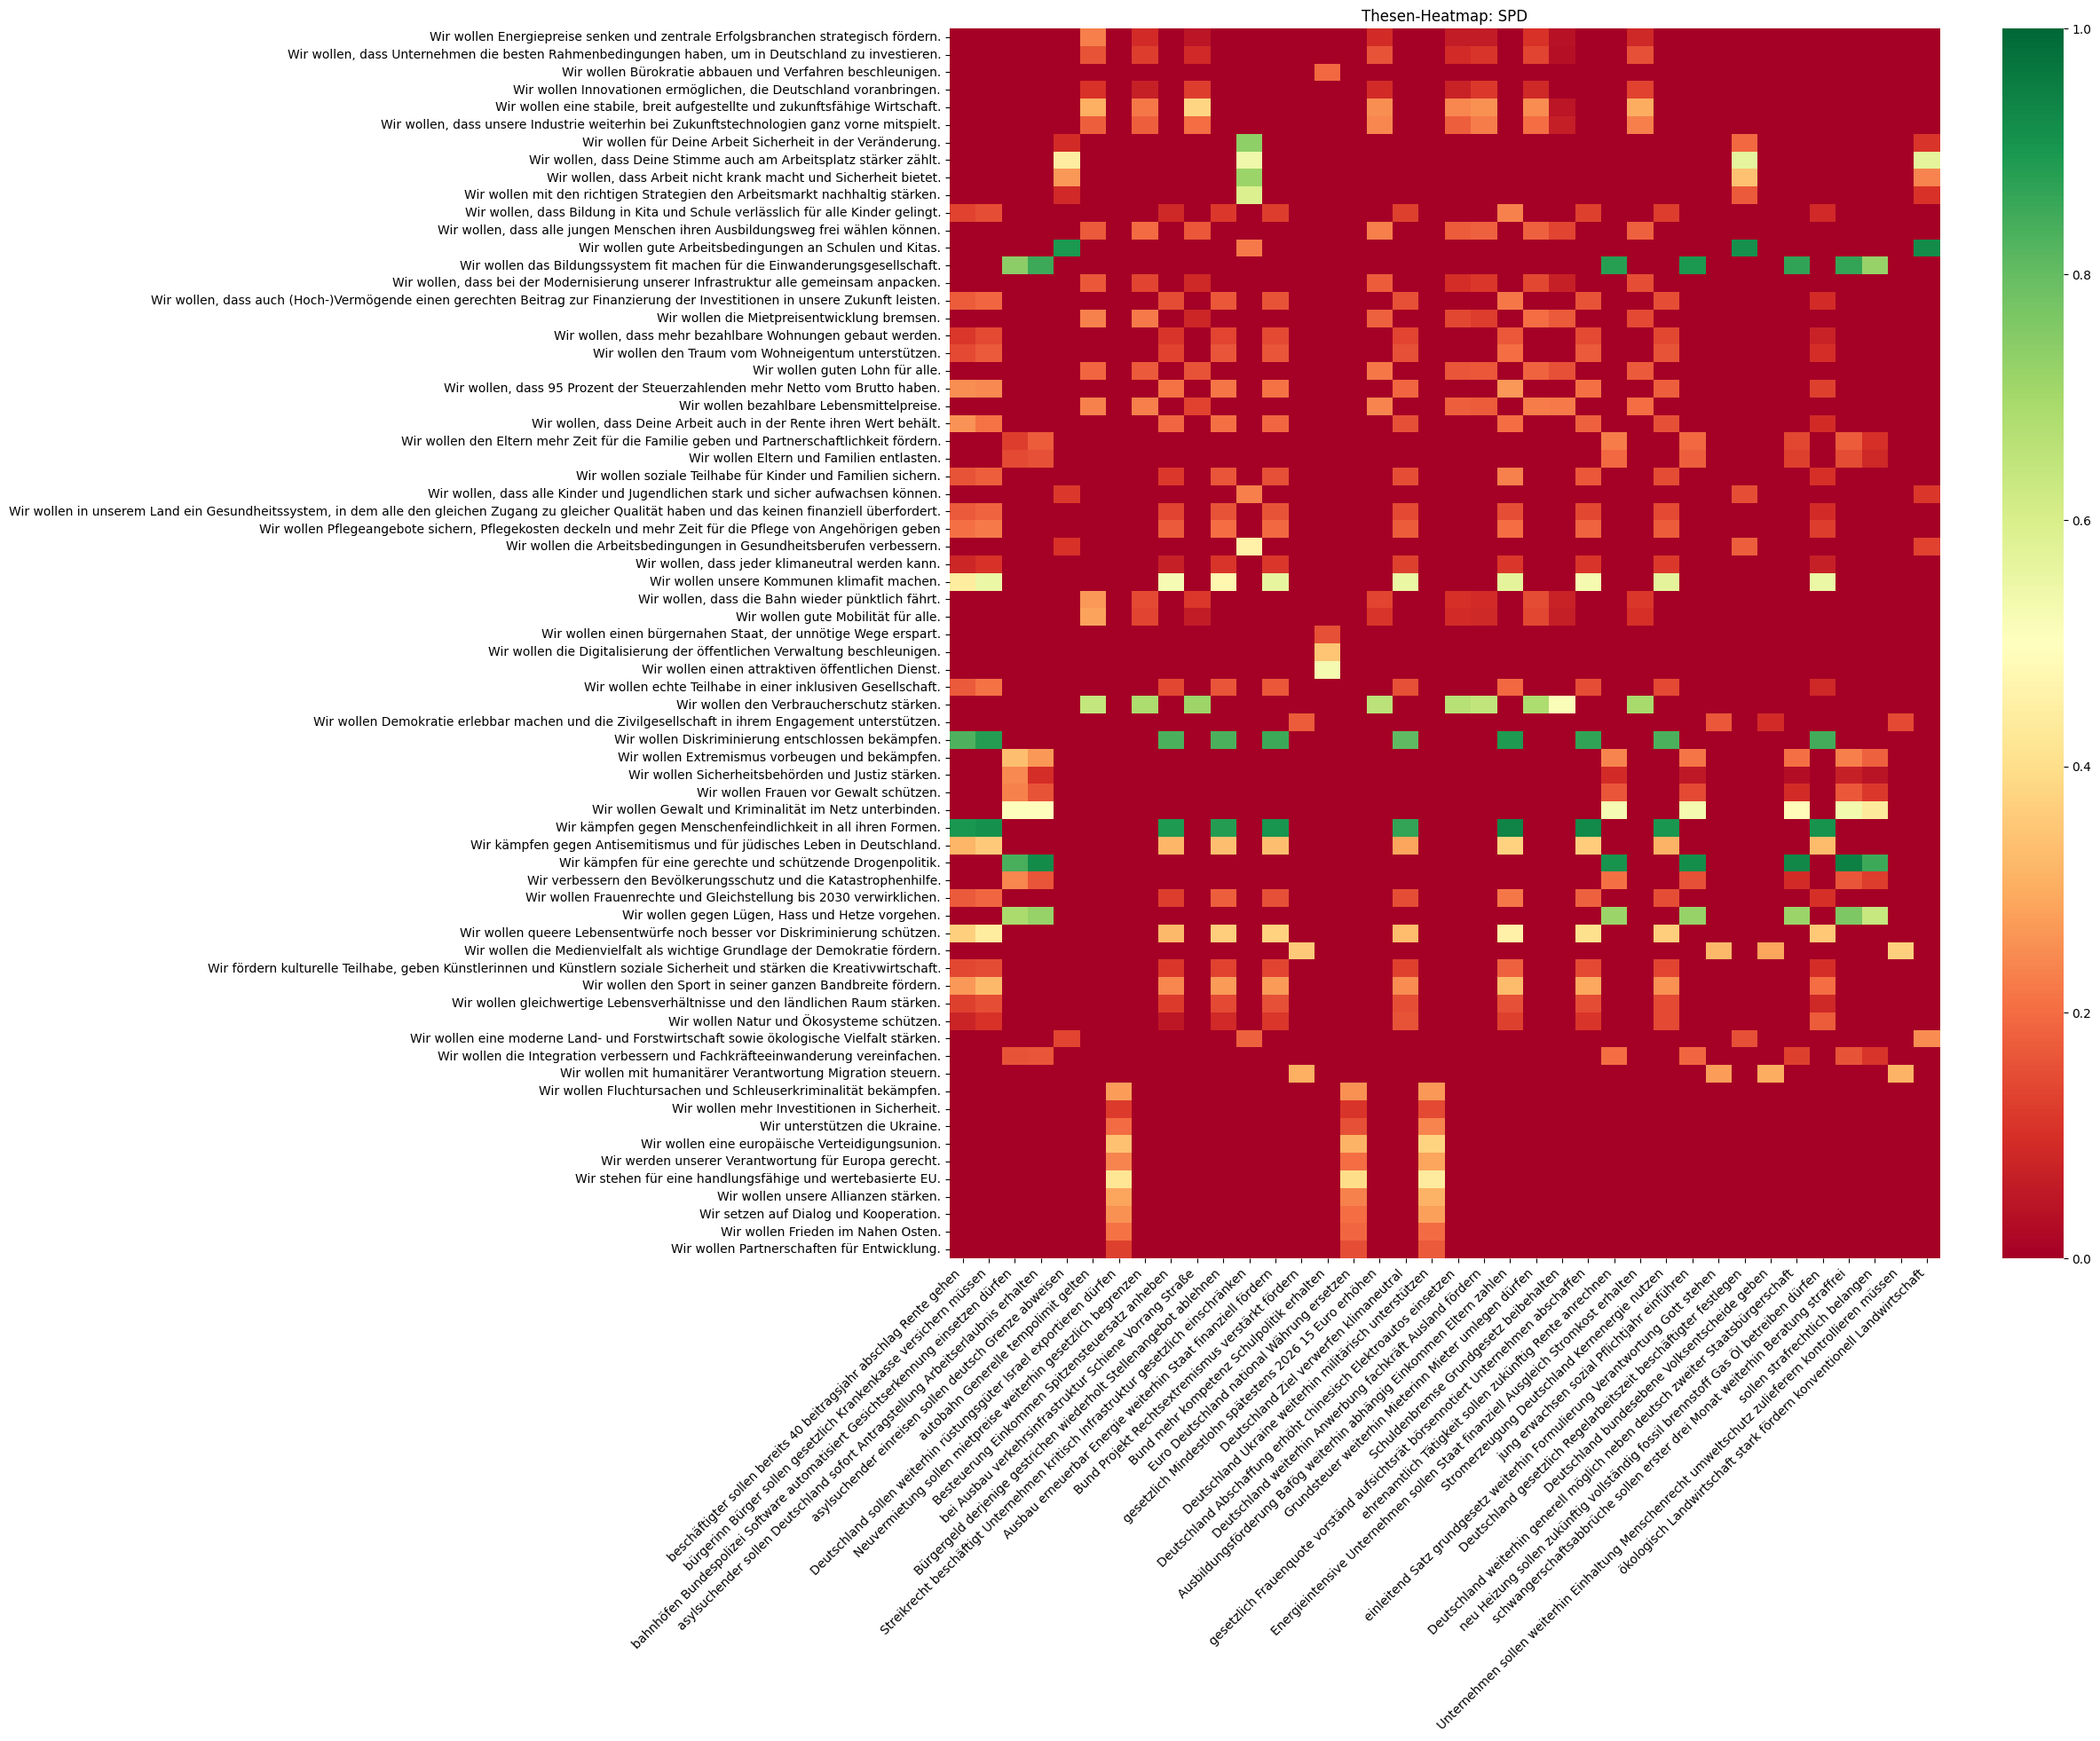

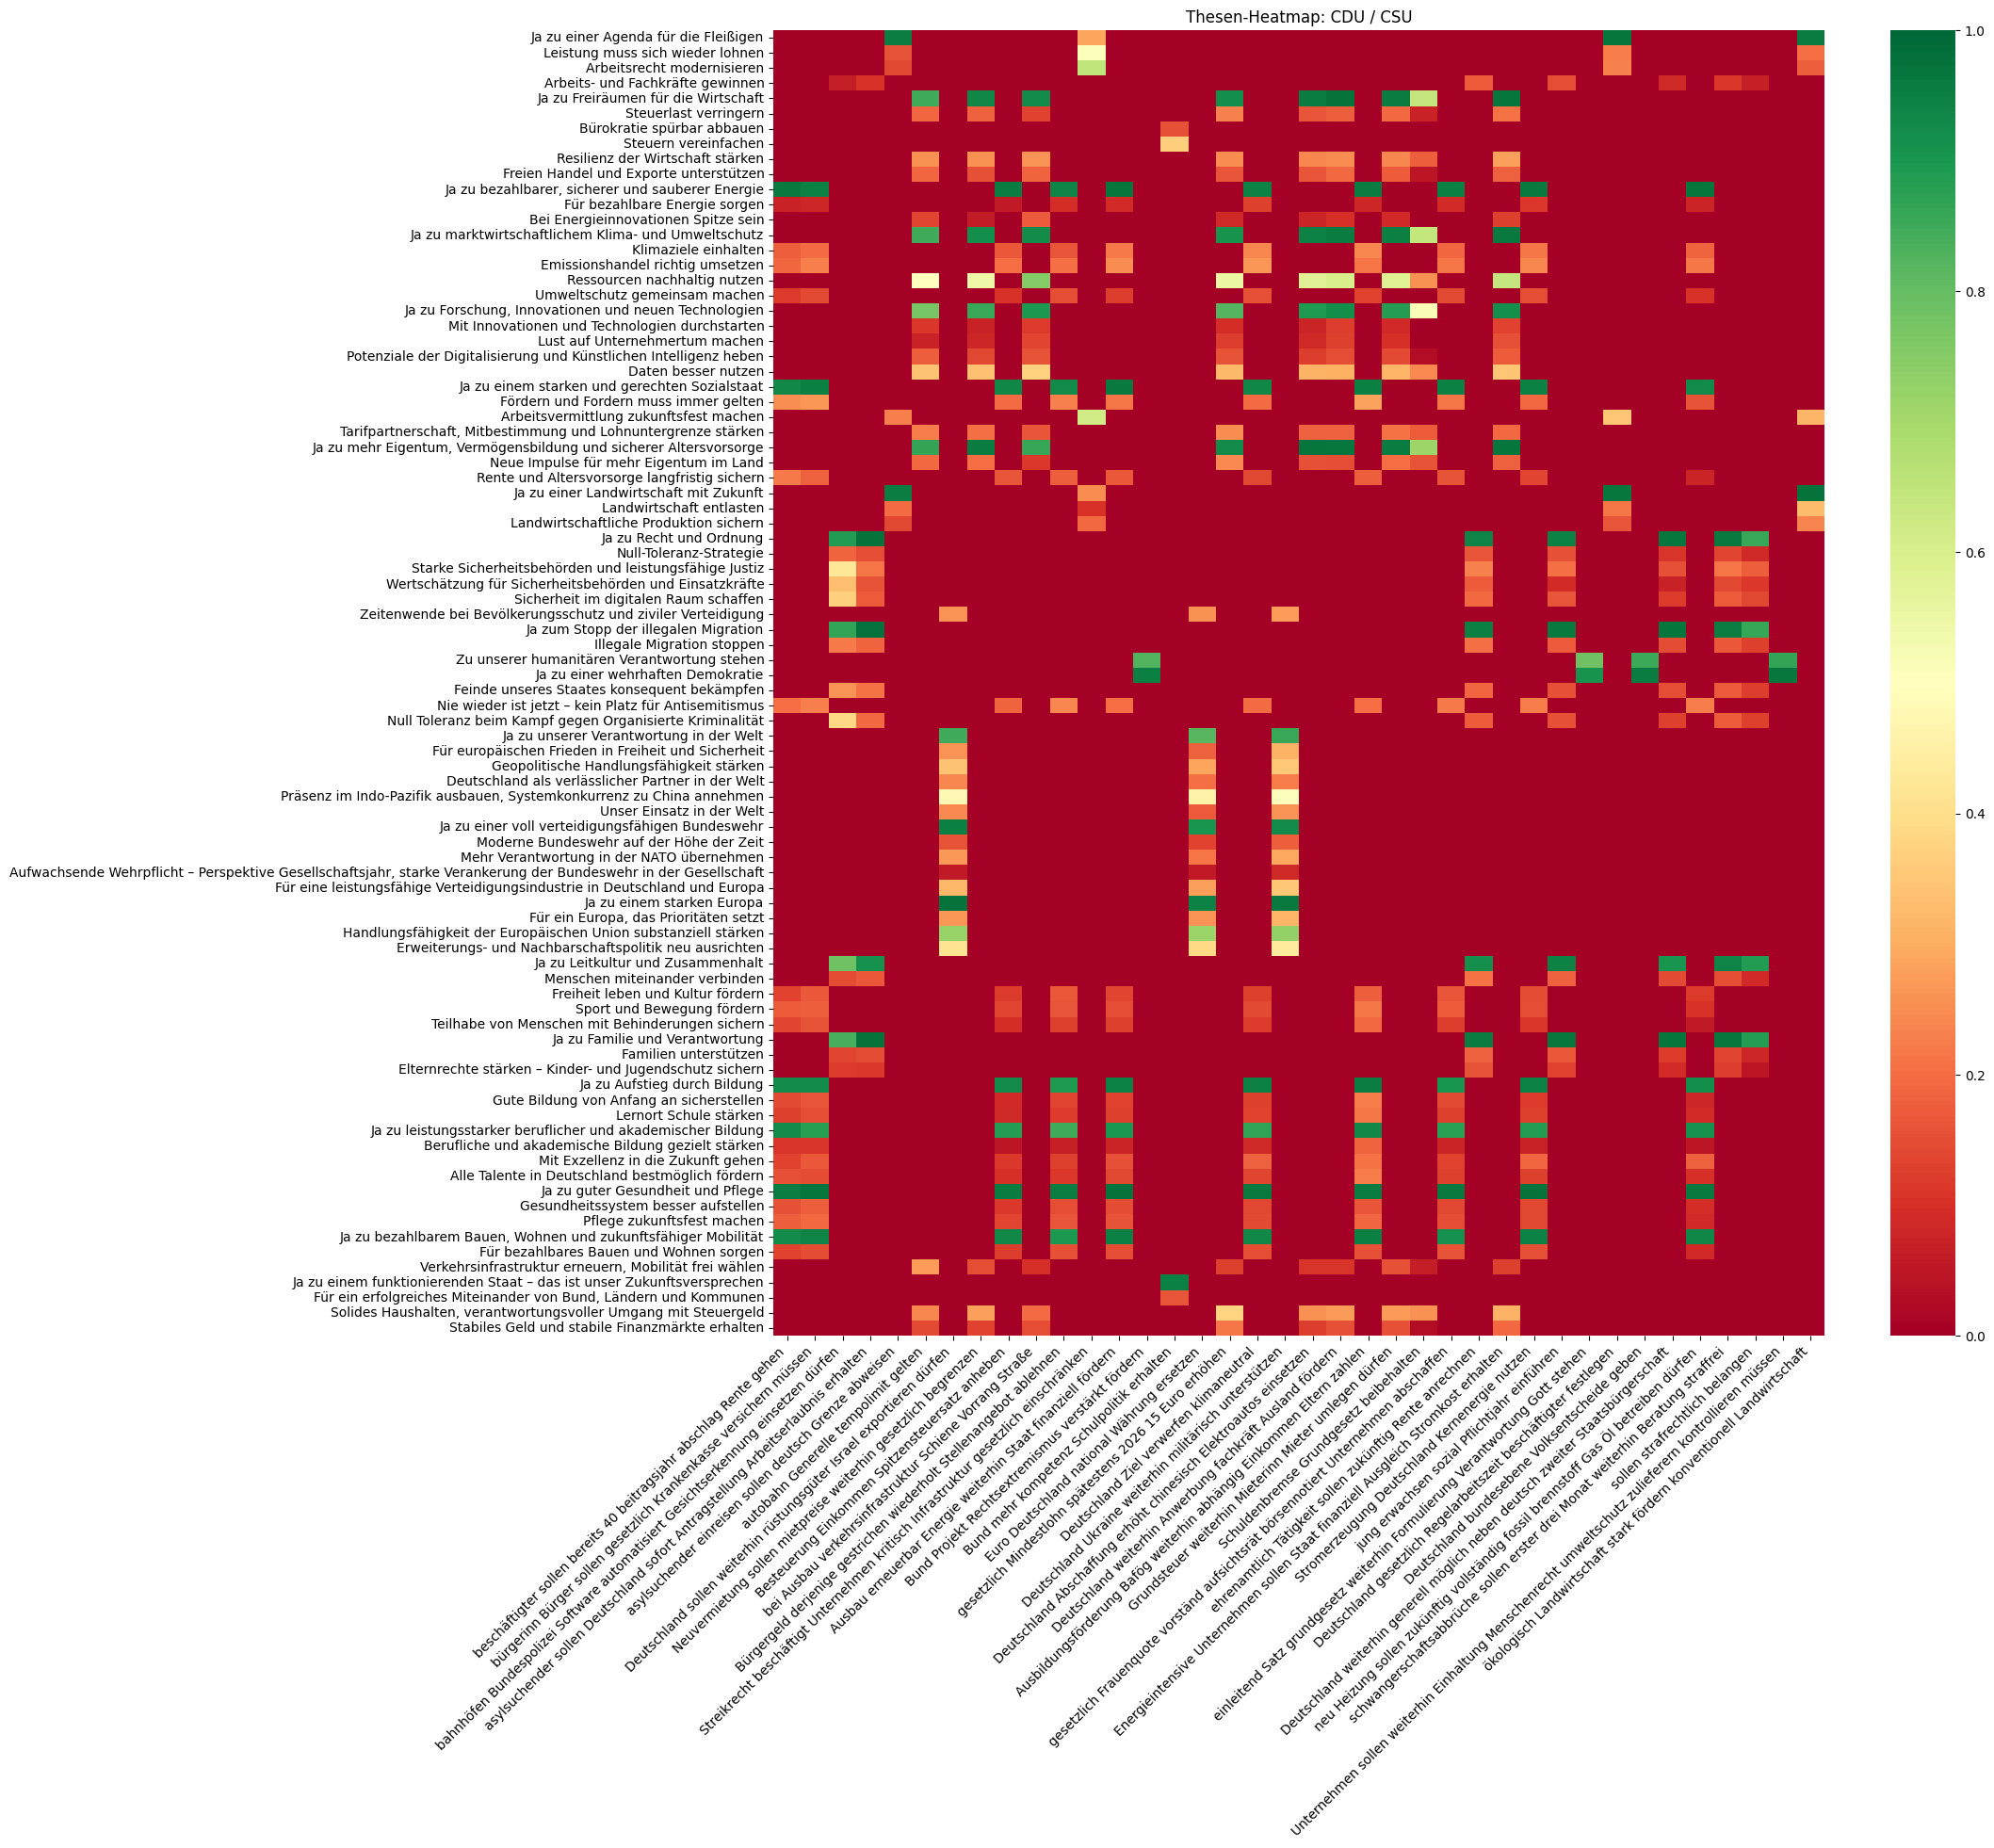

In [ ]:
lable_text_column = 'These_lemmatized'
party_text_column = 'Text_lemmatized'
predicted_theses_dfs_dict, predicted_theses_df = similarity_func_with_category_check(all_party_textes_df,labled_theses_df,lable_text_column,party_text_column, plot=True, sort_by_classification=True)